<a href="https://colab.research.google.com/github/castrokelly/PPGIa/blob/main/atividade_B_regressao_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade B — Regressão da progressão de diabetes

**Objetivo:** treinar, ajustar e comparar modelos de regressão para estimar o nível
quantitativo de progressão da diabetes.

Modelos exigidos pela atividade:

- Árvore de Regressão
- KNN Regressor
- SVR
- MLP Regressor
- Random Forest
- Bagging
- XGBoost Regressor

Métricas:

- coeficiente de determinação \(R^2\);
- erro médio absoluto (MAE).

## Planejamento da resolução

1. Instalar e importar as bibliotecas.
2. Carregar a base `load_diabetes`.
3. Confirmar 442 instâncias, 10 atributos e alvo entre 25 e 346.
4. Criar validação cruzada com 5 folds.
5. Usar pipelines para padronização sem vazamento de dados.
6. Ajustar os hiperparâmetros de cada regressor.
7. Comparar \(R^2\) médio e MAE médio.
8. Selecionar o melhor regressor pelo maior \(R^2\).
9. Gerar predições fora da amostra.
10. Analisar valores observados versus preditos e resíduos.
11. Registrar os parâmetros do melhor modelo.

## 1. Instalação

Instalação do XGBoost.

In [1]:
%pip install -q xgboost

## 2. Importações e configuração

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import clone
from sklearn.datasets import load_diabetes
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    KFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    make_scorer,
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    BaggingRegressor,
)

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost não está instalado. Execute a célula de instalação e reinicie o kernel."
    ) from exc

RANDOM_STATE = 42
N_JOBS = 2  # altere para 1 em ambientes com poucos recursos
pd.set_option("display.max_colwidth", 120)

## 3. Carregamento da base

`as_frame=True` retorna os atributos e o alvo como objetos do Pandas, preservando os
nomes das variáveis.

A base deve possuir:

- 442 instâncias;
- 10 atributos numéricos;
- alvo entre 25 e 346.

In [3]:
X, y = load_diabetes(
    return_X_y=True,
    as_frame=True,
    scaled=True,
)

y = y.rename("progressao_diabetes")

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
display(X.head())
display(y.head())

Dimensão de X: (442, 10)
Dimensão de y: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


,progressao_diabetes
0,151.0
1,75.0
2,141.0
3,206.0
4,135.0


## 4. Auditoria inicial

Os atributos da versão padrão do Scikit-learn já são centralizados e escalados.
Mesmo assim, os modelos sensíveis à escala serão mantidos dentro de um pipeline com
`StandardScaler`, deixando o procedimento explícito e reutilizável.

In [4]:
resumo_diabetes = pd.DataFrame({
    "informação": [
        "Número de instâncias",
        "Número de atributos",
        "Valores ausentes em X",
        "Valores ausentes em y",
        "Mínimo do alvo",
        "Máximo do alvo",
        "Média do alvo",
        "Desvio-padrão do alvo",
    ],
    "valor": [
        X.shape[0],
        X.shape[1],
        int(X.isna().sum().sum()),
        int(y.isna().sum()),
        float(y.min()),
        float(y.max()),
        float(y.mean()),
        float(y.std()),
    ],
})

display(resumo_diabetes)

assert X.shape == (442, 10), f"Dimensão inesperada: {X.shape}"
assert y.shape == (442,)
assert float(y.min()) == 25.0
assert float(y.max()) == 346.0
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0

,informação,valor
0,Número de instâncias,442.000000
1,Número de atributos,10.000000
2,Valores ausentes em X,0.000000
3,Valores ausentes em y,0.000000
4,Mínimo do alvo,25.000000
5,Máximo do alvo,346.000000
6,Média do alvo,152.133484
7,Desvio-padrão do alvo,77.093005


## 5. Protocolo experimental e métricas

A atividade pede validação cruzada com 5 folds. Como o alvo é contínuo, utiliza-se
`KFold` com embaralhamento e semente fixa.

Métricas:

- **\(R^2\):** quanto maior, melhor;
- **MAE:** quanto menor, melhor.

O melhor modelo será selecionado pelo maior \(R^2\) médio.

In [5]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

scoring_regressao = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(
        mean_absolute_error,
        greater_is_better=False,
    ),
}

## 6. Modelos, pipelines e grades de hiperparâmetros

A padronização é inserida nos pipelines de KNN, SVR e MLP.

In [7]:
modelos_regressao = {
    "Árvore de Regressão": {
        "pipeline": Pipeline([
            ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
        ]),
        "param_grid": {
            "model__max_depth": [None, 3, 5, 8, 12],
            "model__min_samples_leaf": [1, 3, 5, 10],
            "model__criterion": ["squared_error", "absolute_error"],
        },
    },
    "KNN Regressor": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsRegressor()),
        ]),
        "param_grid": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
        },
    },
    "SVR": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR()),
        ]),
        "param_grid": {
            "model__kernel": ["linear", "rbf"],
            "model__C": [0.1, 1, 10, 100],
            "model__epsilon": [0.1, 1, 5, 10],
            "model__gamma": ["scale", "auto"],
        },
    },
    "MLP Regressor": {
        "pipeline": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                max_iter=3000,
                early_stopping=True,
                validation_fraction=0.15,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__hidden_layer_sizes": [(50,), (100,), (50, 25)],
            "model__activation": ["relu", "tanh"],
            "model__alpha": [0.0001, 0.001, 0.01],
            "model__learning_rate_init": [0.001, 0.01],
        },
    },
    "Random Forest": {
        "pipeline": Pipeline([
            ("model", RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_leaf": [1, 3, 5],
            "model__max_features": [1.0, "sqrt"],
        },
    },
    "Bagging": {
        "pipeline": Pipeline([
            ("model", BaggingRegressor(
                estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
                random_state=RANDOM_STATE,
                n_jobs=N_JOBS,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100, 200],
            "model__max_samples": [0.7, 1.0],
            "model__max_features": [0.7, 1.0],
        },
    },
    "XGBoost Regressor": {
        "pipeline": Pipeline([
            ("model", XGBRegressor(
                objective="reg:squarederror",
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=1,
                verbosity=0,
            ))
        ]),
        "param_grid": {
            "model__n_estimators": [200, 400],
            "model__max_depth": [2, 3, 5],
            "model__learning_rate": [0.03, 0.1],
            "model__subsample": [0.8, 1.0],
            "model__colsample_bytree": [0.8, 1.0],
        },
    },
}

print("Quantidade de indutores:", len(modelos_regressao))

Quantidade de indutores: 7


## 7. Busca dos melhores hiperparâmetros

Cada indutor é ajustada com `GridSearchCV`. O parâmetro `refit="r2"` determina que
o melhor conjunto de hiperparâmetros é aquele com maior \(R^2\) médio.

O Scikit-learn representa métricas de erro como valores negativos durante a busca.
Por isso, multiplicamos o MAE por `-1` ao montar a tabela final.

In [8]:
resultados_regressao = []
buscas_regressao = {}

for nome, configuracao in modelos_regressao.items():
    print(f"Treinando: {nome}")

    busca = GridSearchCV(
        estimator=configuracao["pipeline"],
        param_grid=configuracao["param_grid"],
        scoring=scoring_regressao,
        refit="r2",
        cv=cv,
        n_jobs=N_JOBS,
        return_train_score=False,
        error_score="raise",
    )
    busca.fit(X, y)

    melhor_indice = busca.best_index_

    resultados_regressao.append({
        "Indutor": nome,
        "R2 médio": busca.cv_results_["mean_test_r2"][melhor_indice],
        "Desvio R2": busca.cv_results_["std_test_r2"][melhor_indice],
        "MAE médio": -busca.cv_results_["mean_test_mae"][melhor_indice],
        "Desvio MAE": busca.cv_results_["std_test_mae"][melhor_indice],
        "Melhores parâmetros": busca.best_params_,
    })

    buscas_regressao[nome] = busca

tabela_regressao = (
    pd.DataFrame(resultados_regressao)
    .sort_values(
        by=["R2 médio", "MAE médio"],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

tabela_regressao_exibicao = tabela_regressao.copy()
for coluna in ["R2 médio", "Desvio R2", "MAE médio", "Desvio MAE"]:
    tabela_regressao_exibicao[coluna] = (
        tabela_regressao_exibicao[coluna].map(lambda valor: round(valor, 4))
    )

display(tabela_regressao_exibicao)

Treinando: Árvore de Regressão
Treinando: KNN Regressor
Treinando: SVR
Treinando: MLP Regressor
Treinando: Random Forest
Treinando: Bagging
Treinando: XGBoost Regressor


,Indutor,R2 médio,Desvio R2,MAE médio,Desvio MAE,Melhores parâmetros
0,SVR,0.4832,0.0695,44.2203,2.0650,"{'model__C': 1, 'model__epsilon': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}"
1,MLP Regressor,0.4730,0.0652,44.1011,1.5598,"{'model__activation': 'relu', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (50, 25), 'model__learning_rate_ini..."
2,XGBoost Regressor,0.4703,0.0739,45.2679,2.5279,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 200, 'm..."
3,Random Forest,0.4605,0.0747,46.0610,2.6435,"{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 200}"
4,Bagging,0.4492,0.0713,46.8371,2.4680,"{'model__max_features': 0.7, 'model__max_samples': 0.7, 'model__n_estimators': 200}"
5,KNN Regressor,0.4450,0.0347,46.2768,1.0091,"{'model__n_neighbors': 21, 'model__p': 2, 'model__weights': 'distance'}"
6,Árvore de Regressão,0.3587,0.1051,48.9207,3.4544,"{'model__criterion': 'squared_error', 'model__max_depth': 3, 'model__min_samples_leaf': 10}"


## 8. Visualização dos resultados

Os gráficos usam escalas separadas porque \(R^2\) e MAE têm interpretações diferentes.

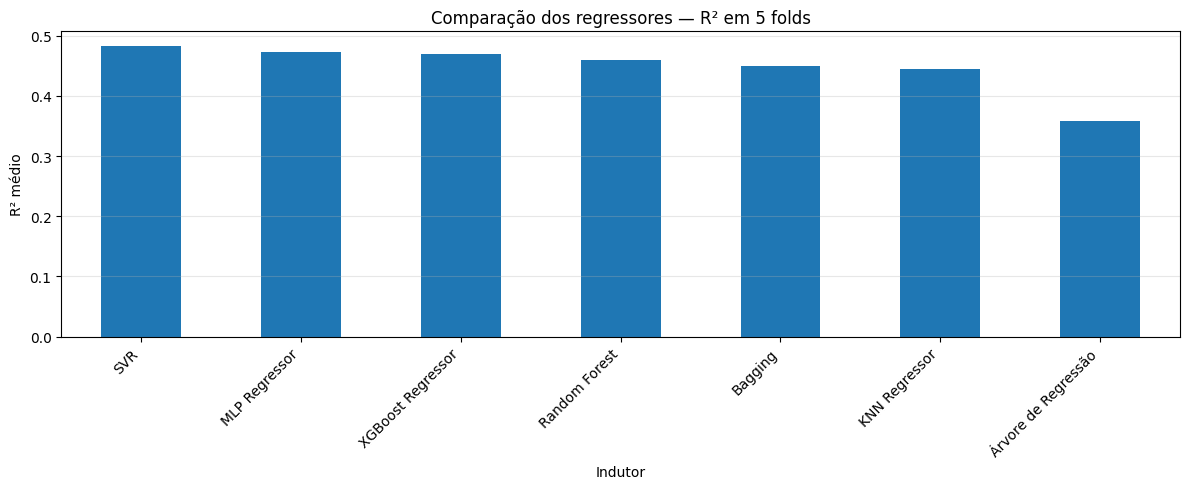

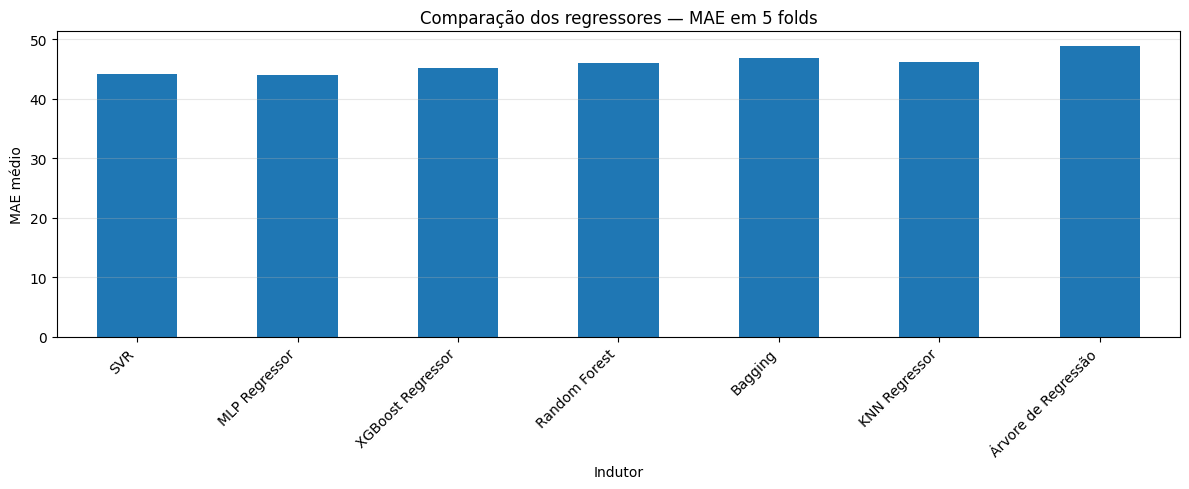

In [9]:
ax = tabela_regressao.set_index("Indutor")["R2 médio"].plot(
    kind="bar",
    figsize=(12, 5),
)
ax.set_ylabel("R² médio")
ax.set_title("Comparação dos regressores — R² em 5 folds")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

ax = tabela_regressao.set_index("Indutor")["MAE médio"].plot(
    kind="bar",
    figsize=(12, 5),
)
ax.set_ylabel("MAE médio")
ax.set_title("Comparação dos regressores — MAE em 5 folds")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Seleção do melhor regressor

In [10]:
nome_melhor_regressor = tabela_regressao.loc[0, "Indutor"]
busca_melhor_regressor = buscas_regressao[nome_melhor_regressor]
melhor_regressor = busca_melhor_regressor.best_estimator_

print("Melhor regressor:", nome_melhor_regressor)
print("Melhores parâmetros:")
display(busca_melhor_regressor.best_params_)

Melhor regressor: SVR
Melhores parâmetros:


{'model__C': 1,
 'model__epsilon': 10,
 'model__gamma': 'scale',
 'model__kernel': 'linear'}

## 10. Predições fora da amostra

Cada valor é predito por um modelo treinado sem aquela instância.

In [11]:
y_pred_oof = cross_val_predict(
    clone(melhor_regressor),
    X,
    y,
    cv=cv,
    n_jobs=N_JOBS,
    method="predict",
)

r2_oof = r2_score(y, y_pred_oof)
mae_oof = mean_absolute_error(y, y_pred_oof)

print(f"R² global das predições OOF: {r2_oof:.4f}")
print(f"MAE global das predições OOF: {mae_oof:.4f}")

R² global das predições OOF: 0.4951
MAE global das predições OOF: 44.2119


## 11. Observado versus predito

Quanto mais próximos os pontos estiverem da diagonal, mais próximas as predições estão
dos valores reais.

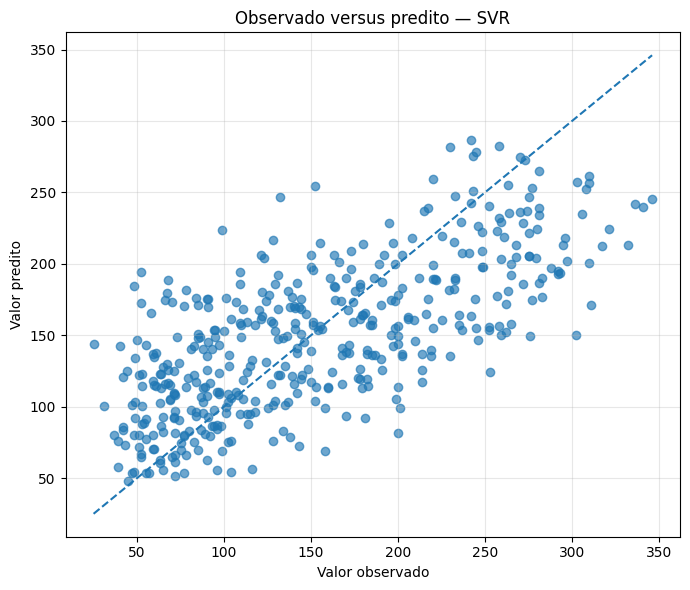

In [12]:
plt.figure(figsize=(7, 6))
plt.scatter(y, y_pred_oof, alpha=0.65)

limite_min = min(float(y.min()), float(y_pred_oof.min()))
limite_max = max(float(y.max()), float(y_pred_oof.max()))
plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
)

plt.xlabel("Valor observado")
plt.ylabel("Valor predito")
plt.title(f"Observado versus predito — {nome_melhor_regressor}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Análise de resíduos

O resíduo é calculado por:

\[
\text{resíduo} = y_{real} - y_{predito}
\]

Uma distribuição aproximadamente equilibrada em torno de zero é desejável.

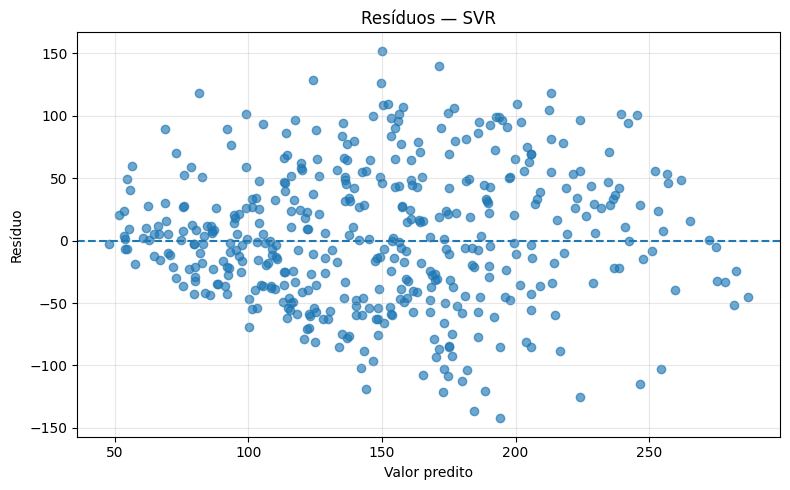

,resíduo
count,442.000000
mean,3.010671
std,54.695960
min,-142.325723
25%,-36.180277
50%,0.267407
75%,42.916866
max,152.059065


In [13]:
residuos = y.to_numpy() - y_pred_oof

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_oof, residuos, alpha=0.65)
plt.axhline(0, linestyle="--")
plt.xlabel("Valor predito")
plt.ylabel("Resíduo")
plt.title(f"Resíduos — {nome_melhor_regressor}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

resumo_residuos = pd.Series(residuos, name="resíduo").describe()
display(resumo_residuos.to_frame())

## 13. Avaliação média do melhor modelo por fold

Esta tabela fornece as métricas exatamente no formato do protocolo da atividade.

In [14]:
avaliacao_melhor_regressor = cross_validate(
    clone(melhor_regressor),
    X,
    y,
    cv=cv,
    scoring=scoring_regressao,
    n_jobs=N_JOBS,
)

r2_folds = avaliacao_melhor_regressor["test_r2"]
mae_folds = -avaliacao_melhor_regressor["test_mae"]

tabela_folds_regressao = pd.DataFrame({
    "fold": np.arange(1, 6),
    "R2": r2_folds,
    "MAE": mae_folds,
})

display(tabela_folds_regressao.round(4))

media_r2 = r2_folds.mean()
media_mae = mae_folds.mean()

print(f"R² médio: {media_r2:.4f}")
print(f"MAE médio: {media_mae:.4f}")

,fold,R2,MAE
0,1,0.4611,42.7022
1,2,0.5558,42.0214
2,3,0.4159,46.7548
3,4,0.5744,42.9330
4,5,0.4087,46.6901


R² médio: 0.4832
MAE médio: 44.2203


## 14. B.1 — Parâmetros do melhor modelo

In [15]:
parametros_completos = busca_melhor_regressor.best_params_
parametros_limpos = {
    chave.replace("model__", ""): valor
    for chave, valor in parametros_completos.items()
}

print("Parâmetros completos do GridSearchCV:")
display(parametros_completos)

print("\nParâmetros do estimador, sem o prefixo do pipeline:")
display(parametros_limpos)

Parâmetros completos do GridSearchCV:


{'model__C': 1,
 'model__epsilon': 10,
 'model__gamma': 'scale',
 'model__kernel': 'linear'}


Parâmetros do estimador, sem o prefixo do pipeline:


{'C': 1, 'epsilon': 10, 'gamma': 'scale', 'kernel': 'linear'}

## 15. Resposta final da Atividade B

In [16]:
print("=" * 80)
print("MELHOR REGRESSOR")
print("=" * 80)
print(f"Indutor: {nome_melhor_regressor}")
print(f"R² médio: {media_r2:.4f}")
print(f"MAE médio: {media_mae:.4f}")

print("\nB.1) Parâmetros utilizados no treinamento")
print(parametros_limpos)

MELHOR REGRESSOR
Indutor: SVR
R² médio: 0.4832
MAE médio: 44.2203

B.1) Parâmetros utilizados no treinamento
{'C': 1, 'epsilon': 10, 'gamma': 'scale', 'kernel': 'linear'}


## 16. Ajuste final opcional

O modelo final pode ser treinado em todas as 442 instâncias depois da avaliação.

In [ ]:
modelo_final_regressao = clone(melhor_regressor)
modelo_final_regressao.fit(X, y)

print("Modelo final ajustado em todas as 442 instâncias.")